# 04 — Feature Analysis v2 (ASTFS-Inspired Per-Crop Band Selection)

Per-crop band selection following the ASTFS methodology (Yin et al. 2020, RS 12(1):162).

| Stage | Method | Cost | Output |
|---|---|---|---|
| 1 — Per-crop SIglobal | GSI per crop vs. all others | Very low | Top-K candidates per crop |
| 2 — Binary CNN Forward Selection | Binary U-Net oracle (crop_i vs. rest), metric = IoU(class 1) | Medium | K*_i bands per crop |
| 3 — Union → Stage 3 Exp C | Union of all per-crop selected features | — | Final compact band set |

**Key difference vs v1 (global selection):**
- Stage 1 ranks bands *per crop* using per-crop SIglobal (not global mean across all crops).
- Stage 2 trains a *binary* classifier (crop i vs. rest) so the oracle focuses exclusively on separating each crop from all others.
- Output: a per-crop results table {Crop | Key Dates | Key Bands | K*_i} matching ASTFS Table 3.

**Reference:** Yin et al. (2020). "Automatic Spectro-Temporal Feature Selection for Crop Mapping."
Remote Sensing 12(1):162. https://doi.org/10.3390/rs12010162

## Configuration

In [12]:
import sys, os, re
from glob import glob
sys.path.append("../")

# ── Data paths ────────────────────────────────────────────────────────────────
PROCESSED_DIR    = "/Volumes/T7/research-crop-mapping-geoai/data/processed"
S2_PROCESSED_DIR = os.path.join(PROCESSED_DIR, "s2")
CDL_FILTERED     = os.path.join(PROCESSED_DIR, "cdl", "cdl_2022_study_area_filtered.tif")
FIGURES_DIR      = "../documents/thesis/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Feature analysis uses 2022 ONLY — selected K* bands are year-agnostic
S2_PROCESSED = sorted([
    p for p in glob(f"{S2_PROCESSED_DIR}/*_processed.tif")
    if os.path.basename(p).split("_")[1] == "2022"
])

S2_BAND_NAMES = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

# ── MLflow ────────────────────────────────────────────────────────────────────
MLFLOW_TRACKING_URI = "https://mlflow-geoai.stelarea.com"
MLFLOW_EXPERIMENT   = "cropmap_feature_analysis_s2"

# ── Stage 1 parameters ────────────────────────────────────────────────────────
SAMPLE_FRACTION = 0.05    # 5% of valid pixels — all 10 classes well represented
TOP_K_PER_CROP  = 20      # top-K candidates per crop (by per-crop SIglobal)

# ── Stage 2 parameters ────────────────────────────────────────────────────────
S2_ENCODER    = "resnet18"
S2_PATCH_SIZE = 128         # 128px → more patches → lower IoU variance per step
S2_STRIDE     = 128
S2_MIN_VALID  = 0.3         # fraction of patch pixels that must be a KEEP_CLASS
S2_EPOCHS     = 15
S2_PATIENCE   = 5
S2_DELTA      = 0.005       # minimum IoU(class 1) gain to accept a band
S2_NO_IMPROVE = 5           # consecutive rejections before stopping per crop
S2_MAX_BANDS  = 20          # max bands per crop

# ── Classes ───────────────────────────────────────────────────────────────────
# Fallow/Idle Cropland (61) → background (class 0); not in KEEP_CLASSES
KEEP_CLASSES = [3, 6, 24, 36, 37, 54, 69, 75, 76, 220]
CLASS_REMAP  = {cls_id: i + 1 for i, cls_id in enumerate(KEEP_CLASSES)}
NUM_CLASSES  = len(KEEP_CLASSES) + 1   # 11: 0=bg + 1-10=crops

CDL_CLASS_NAMES = {
    3: "Rice", 6: "Sunflower", 24: "Winter Wheat",
    36: "Alfalfa", 37: "Other Hay", 54: "Tomatoes",
    69: "Grapes", 75: "Almonds", 76: "Walnuts", 220: "Plums",
}

# ── Verify ────────────────────────────────────────────────────────────────────
print(f"S2 processed ({len(S2_PROCESSED)} files):")
for p in S2_PROCESSED:
    print(f"  {'✅' if os.path.exists(p) else '❌'} {os.path.basename(p)}")
print(f"\nCDL filtered : {'✅' if os.path.exists(CDL_FILTERED) else '❌'} {CDL_FILTERED}")
print(f"Figures dir  : {os.path.abspath(FIGURES_DIR)}")
print(f"MLflow URI   : {MLFLOW_TRACKING_URI}")
print(f"KEEP_CLASSES : {KEEP_CLASSES}")
print(f"NUM_CLASSES  : {NUM_CLASSES}")
print(f"\nStage 2 params: epochs={S2_EPOCHS}, patience={S2_PATIENCE}, "
      f"no_improve={S2_NO_IMPROVE}, delta={S2_DELTA}, max_bands={S2_MAX_BANDS}")


S2 processed (25 files):
  ✅ S2H_2022_2022_01_01_processed.tif
  ✅ S2H_2022_2022_01_16_processed.tif
  ✅ S2H_2022_2022_01_31_processed.tif
  ✅ S2H_2022_2022_02_15_processed.tif
  ✅ S2H_2022_2022_03_02_processed.tif
  ✅ S2H_2022_2022_03_17_processed.tif
  ✅ S2H_2022_2022_04_01_processed.tif
  ✅ S2H_2022_2022_04_16_processed.tif
  ✅ S2H_2022_2022_05_01_processed.tif
  ✅ S2H_2022_2022_05_16_processed.tif
  ✅ S2H_2022_2022_05_31_processed.tif
  ✅ S2H_2022_2022_06_15_processed.tif
  ✅ S2H_2022_2022_06_30_processed.tif
  ✅ S2H_2022_2022_07_15_processed.tif
  ✅ S2H_2022_2022_07_30_processed.tif
  ✅ S2H_2022_2022_08_14_processed.tif
  ✅ S2H_2022_2022_08_29_processed.tif
  ✅ S2H_2022_2022_09_13_processed.tif
  ✅ S2H_2022_2022_09_28_processed.tif
  ✅ S2H_2022_2022_10_13_processed.tif
  ✅ S2H_2022_2022_10_28_processed.tif
  ✅ S2H_2022_2022_11_12_processed.tif
  ✅ S2H_2022_2022_11_27_processed.tif
  ✅ S2H_2022_2022_12_12_processed.tif
  ✅ S2H_2022_2022_12_27_processed.tif

CDL filtered : ✅ /Volume

In [13]:
import src.utils.band_selection as bs
print("band_selection module loaded:", bs.__file__)


band_selection module loaded: /Users/dikaizm/Documents/PROGRAMMING/ml-ai/research-crop-mapping-thesis/research-crop-mapping-geoai/notebooks/../src/utils/band_selection.py


In [14]:
import numpy as np
import rasterio
import pandas as pd

S2_NODATA = -9999.0

# ── Stack all processed S2 files ──────────────────────────────────────────────
all_arrays    = []
all_bandnames = []

for s2_path in S2_PROCESSED:
    fname = os.path.basename(s2_path)
    m = re.search(r"_(\d{4})_(\d{2})_(\d{2})_processed", fname)
    date_str = f"{m.group(1)}{m.group(2)}{m.group(3)}" if m else fname[:8]
    with rasterio.open(s2_path) as src:
        arr = src.read().astype(np.float32)
    arr[arr == S2_NODATA] = np.nan
    all_arrays.append(arr)
    all_bandnames.extend([f"{b}_{date_str}" for b in S2_BAND_NAMES])

stacked      = np.concatenate(all_arrays, axis=0)   # (n_channels, H, W)
n_channels, H, W = stacked.shape
band_names   = all_bandnames

print(f"Stacked S2 : {n_channels} channels × {H} × {W} px")

# ── Load CDL ──────────────────────────────────────────────────────────────────
with rasterio.open(CDL_FILTERED) as src:
    cdl = src.read(1).astype(np.int32)

assert cdl.shape == (H, W), f"Shape mismatch: CDL {cdl.shape} vs S2 ({H},{W})"
print(f"CDL shape  : {cdl.shape}")

unique, counts = np.unique(cdl[np.isin(cdl, KEEP_CLASSES)], return_counts=True)
print(f"\nActive CDL classes:")
for u, c in zip(unique, counts):
    print(f"  {CDL_CLASS_NAMES.get(int(u), u):20s} (id={u:3d}): {c:>10,} px  ({100*c/cdl.size:.1f}%)")

# ── Flatten + filter labeled pixels ──────────────────────────────────────────
img_2d = stacked.reshape(n_channels, -1).T
lbl_1d = cdl.flatten()

# Filter by CDL class ONLY — do NOT require all channels to be finite.
# Multi-temporal S2 has cloud-masked NaN on different dates per pixel;
# requiring np.isfinite(img_2d).all(axis=1) across 275 channels eliminates
# ~99.99% of crop pixels (every pixel is cloudy on at least one of 25 dates).
# GSI uses pandas mean/std with skipna=True → NaN bands are handled correctly.
# RF (not used in v2) would need NaN filling before sklearn.
valid_mask = np.isin(lbl_1d, KEEP_CLASSES)
img_valid  = img_2d[valid_mask]   # fancy indexing → copy, safe to del img_2d later
lbl_valid  = lbl_1d[valid_mask]

n_fully_clean = int(np.isfinite(img_valid).all(axis=1).sum())
print(f"\nLabeled crop pixels : {len(lbl_valid):,}  "
      f"({100*len(lbl_valid)/len(lbl_1d):.1f}% of {len(lbl_1d):,} total)")
print(f"Fully cloud-free    : {n_fully_clean:,} "
      f"({100*n_fully_clean/max(len(lbl_valid),1):.2f}%) — all {n_channels} channels finite")
print("NaN handling        : pandas skipna=True in GSI → no imputation needed for Stage 1")

# ── Sample for Stage 1 ───────────────────────────────────────────────────────
rng = np.random.default_rng(42)
n   = min(len(lbl_valid), max(1000, int(len(lbl_valid) * SAMPLE_FRACTION)))
idx = rng.choice(len(lbl_valid), n, replace=False)

df        = pd.DataFrame(img_valid[idx], columns=all_bandnames)
df.insert(0, "class_label", lbl_valid[idx].astype(int))
CLASS_COL = "class_label"

print(f"\nSampled    : {len(df):,} pixels  (SAMPLE_FRACTION={SAMPLE_FRACTION})")
print(f"\nClass distribution in sample:")
for cls_id, cnt in df[CLASS_COL].value_counts().sort_index().items():
    print(f"  {CDL_CLASS_NAMES.get(int(cls_id), cls_id):20s} (id={cls_id:3d}): {cnt:>7,}")

del stacked, img_2d


Stacked S2 : 275 channels × 4684 × 5596 px
CDL shape  : (4684, 5596)

Active CDL classes:
  Rice                 (id=  3):  1,731,503 px  (6.6%)
  Sunflower            (id=  6):    913,565 px  (3.5%)
  Winter Wheat         (id= 24):  1,231,983 px  (4.7%)
  Alfalfa              (id= 36):    575,672 px  (2.2%)
  Other Hay            (id= 37):    375,842 px  (1.4%)
  Tomatoes             (id= 54):  1,942,579 px  (7.4%)
  Grapes               (id= 69):    327,883 px  (1.3%)
  Almonds              (id= 75):  3,011,056 px  (11.5%)
  Walnuts              (id= 76):  2,387,806 px  (9.1%)
  Plums                (id=220):    560,637 px  (2.1%)

Labeled crop pixels : 13,058,526  (49.8% of 26,211,664 total)
Fully cloud-free    : 469 (0.00%) — all 275 channels finite
NaN handling        : pandas skipna=True in GSI → no imputation needed for Stage 1

Sampled    : 652,926 pixels  (SAMPLE_FRACTION=0.05)

Class distribution in sample:
  Rice                 (id=  3):  86,531
  Sunflower            (id= 

---
# Stage 1 — Per-Crop SIglobal Ranking

**Goal:** For each crop, rank all channels by the per-crop Global Separation Index (SIglobal).

$$\text{SI}_{ij}(b) = \frac{|\mu_i(b) - \mu_j(b)|}{1.96 \cdot (\sigma_i(b) + \sigma_j(b))}$$

$$\text{SI}_{\text{global},i}(b) = \frac{1}{C-1} \sum_{j \neq i} \text{SI}_{ij}(b)$$

Unlike v1 (global mean across all crops), here we use the **per-crop** SIglobal so each crop gets its own ranked candidate list.
This directly follows ASTFS Step 2 (Yin et al. 2020, Section 3.2).

## 1.1 — Start Stage 1 MLflow Run

In [15]:
import os
os.environ["MLFLOW_DISABLE_TELEMETRY"] = "true"  # must be set before import
import mlflow
from datetime import datetime

assert df is not None and len(df) > 0, "Run the data loading cell first."
print(f"Stage 1 input  : {len(df):,} pixels × {len(all_bandnames)} channels")
print(f"Classes present: {sorted(df[CLASS_COL].unique())}")

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = mlflow.MlflowClient()

if mlflow.active_run():
    print(f"[cleanup] Closing stale run: {mlflow.active_run().info.run_id}")
    mlflow.end_run(status="FAILED")

exp = client.get_experiment_by_name(MLFLOW_EXPERIMENT)
if exp is None:
    print(f"[INFO] Creating experiment '{MLFLOW_EXPERIMENT}'...")
    experiment_id = client.create_experiment(MLFLOW_EXPERIMENT)
    exp = client.get_experiment(experiment_id)
elif exp.lifecycle_stage == "deleted":
    client.restore_experiment(exp.experiment_id)
    exp = client.get_experiment(exp.experiment_id)
else:
    print(f"Experiment found (id={exp.experiment_id}) ✅")

assert exp.artifact_location.startswith("mlflow-artifacts:"), (
    f"Server not proxying artifacts — got: {exp.artifact_location}\n"
    "Redeploy server with --serve-artifacts"
)
print(f"[OK] Artifact proxy active: {exp.artifact_location}")

mlflow.set_experiment(MLFLOW_EXPERIMENT)
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d-%H%M%S")

stage1_run = mlflow.start_run(run_name=f"stage1v2_gsi_percrop_{RUN_TIMESTAMP}")

_artifact_uri = mlflow.get_artifact_uri()
MLFLOW_HAS_PROXY = _artifact_uri.startswith("mlflow-artifacts:")
print(f"\nRun artifact URI : {_artifact_uri}")

mlflow.log_params({
    "stage":             "1_per_crop_siglobal",
    "version":           "v2",
    "n_images":          len(S2_PROCESSED),
    "n_bands_per_image": len(S2_BAND_NAMES),
    "total_channels":    n_channels,
    "sample_fraction":   SAMPLE_FRACTION,
    "n_sampled_pixels":  len(df),
    "top_k_per_crop":    TOP_K_PER_CROP,
    "keep_classes":      str(KEEP_CLASSES),
    "num_classes":       NUM_CLASSES,
})

print(f"\nMLflow tracking URI : {MLFLOW_TRACKING_URI}")
print(f"Experiment          : {MLFLOW_EXPERIMENT}")
print(f"Stage 1 run ID      : {stage1_run.info.run_id}")


Stage 1 input  : 652,926 pixels × 275 channels
Classes present: [np.int64(3), np.int64(6), np.int64(24), np.int64(36), np.int64(37), np.int64(54), np.int64(69), np.int64(75), np.int64(76), np.int64(220)]
[cleanup] Closing stale run: 526a78757dd64c168c05c70c1af8e8ff
🏃 View run stage2v2_binary_fwd_20260310-155112 at: https://mlflow-geoai.stelarea.com/#/experiments/26/runs/526a78757dd64c168c05c70c1af8e8ff
🧪 View experiment at: https://mlflow-geoai.stelarea.com/#/experiments/26
Experiment found (id=26) ✅
[OK] Artifact proxy active: mlflow-artifacts:/26

Run artifact URI : mlflow-artifacts:/26/9e268ed0aae64987aa43400939e71782/artifacts

MLflow tracking URI : https://mlflow-geoai.stelarea.com
Experiment          : cropmap_feature_analysis_s2
Stage 1 run ID      : 9e268ed0aae64987aa43400939e71782


## 1.2 — Compute Per-Crop SIglobal

In [16]:
import matplotlib.pyplot as plt

print("Computing per-crop GSI (SIglobal)...")
# gsi_df shape: (n_bands, n_classes)
# gsi_df[crop_id] = per-crop SIglobal Series indexed by band name
gsi_df = bs.calculate_gsi(df, CLASS_COL)

print(f"\ngsi_df shape: {gsi_df.shape}  (bands × classes)")
print(f"Classes (columns): {list(gsi_df.columns)}")

# Show top 5 bands per crop
print("\nTop 5 bands by per-crop SIglobal:")
for crop_id in KEEP_CLASSES:
    if crop_id not in gsi_df.columns:
        print(f"  {CDL_CLASS_NAMES[crop_id]:20s} (id={crop_id}): not in sample")
        continue
    top5 = gsi_df[crop_id].sort_values(ascending=False).head(5)
    top5_str = ", ".join(top5.index.tolist())
    print(f"  {CDL_CLASS_NAMES[crop_id]:20s} (id={crop_id:3d}): {top5_str}")


Computing per-crop GSI (SIglobal)...

gsi_df shape: (275, 10)  (bands × classes)
Classes (columns): [54, 37, 75, 36, 220, 3, 24, 6, 76, 69]

Top 5 bands by per-crop SIglobal:
  Rice                 (id=  3): B12_20220730, B8A_20220516, B11_20220730, B11_20220715, B11_20220630
  Sunflower            (id=  6): B8A_20220401, B8A_20220317, B8_20220401, B7_20220401, B8_20220317
  Winter Wheat         (id= 24): B4_20220630, B5_20220630, B4_20220615, B12_20220715, B11_20220630
  Alfalfa              (id= 36): B8A_20220401, B7_20220401, B8_20220401, B6_20220401, B8A_20220516
  Other Hay            (id= 37): B11_20220630, B11_20220715, B5_20220630, B11_20220730, B4_20220630
  Tomatoes             (id= 54): B8A_20220416, B8A_20220401, B8A_20220317, B8_20220401, B8_20220416
  Grapes               (id= 69): B11_20220630, B11_20220715, B11_20220615, B11_20220531, B12_20220715
  Almonds              (id= 75): B8A_20220416, B7_20220416, B7_20220401, B8_20220416, B8A_20220401
  Walnuts              (i

## 1.3 — Build Per-Crop Candidate Lists & Log Stage 1

Per-crop candidates (top-K by per-crop SIglobal):
  Rice                 (id=3): 20 candidates
  Sunflower            (id=6): 20 candidates
  Winter Wheat         (id=24): 20 candidates
  Alfalfa              (id=36): 20 candidates
  Other Hay            (id=37): 20 candidates
  Tomatoes             (id=54): 20 candidates
  Grapes               (id=69): 20 candidates
  Almonds              (id=75): 20 candidates
  Walnuts              (id=76): 20 candidates
  Plums                (id=220): 20 candidates


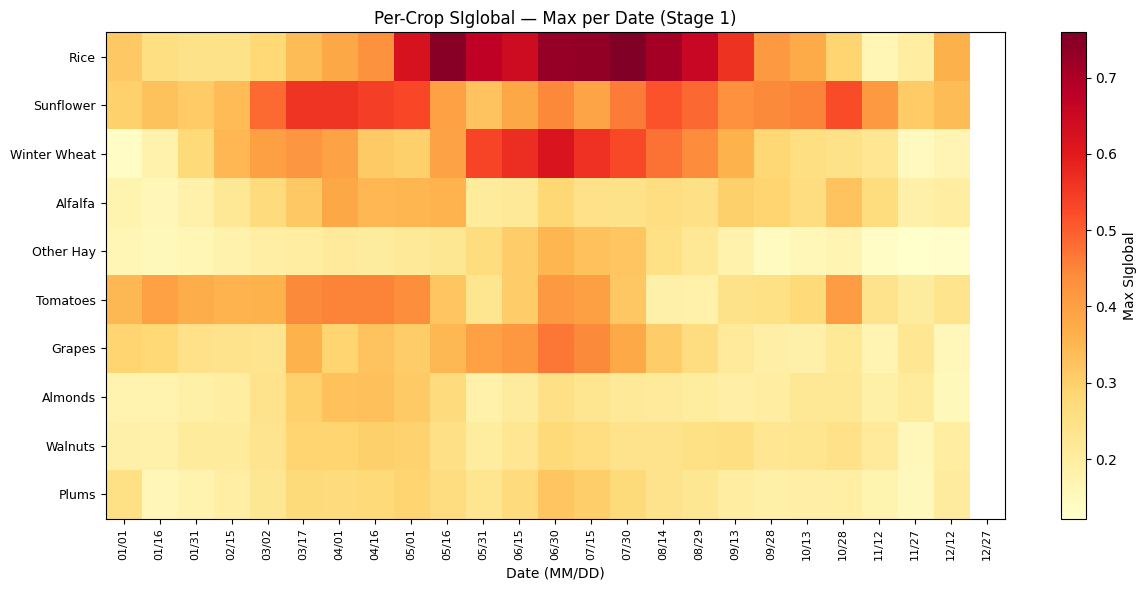

Saved: ../documents/thesis/figures/stage1v2_siglobal_heatmap.png
🏃 View run stage1v2_gsi_percrop_20260310-160400 at: https://mlflow-geoai.stelarea.com/#/experiments/26/runs/9e268ed0aae64987aa43400939e71782
🧪 View experiment at: https://mlflow-geoai.stelarea.com/#/experiments/26

✅ Stage 1 logged to MLflow  (run_id: 9e268ed0aae64987aa43400939e71782)


In [17]:
import tempfile, pathlib

# Global mean GSI (fallback for crops not in sample)
gsi_mean_global = gsi_df.mean(axis=1).sort_values(ascending=False)

# ── Build per-crop candidate lists ────────────────────────────────────────────
candidates_per_crop = {}
for crop_id in KEEP_CLASSES:
    if crop_id in gsi_df.columns:
        si_crop = gsi_df[crop_id].sort_values(ascending=False)
        candidates_per_crop[crop_id] = si_crop.head(TOP_K_PER_CROP).index.tolist()
    else:
        print(f"[WARN] Crop {crop_id} ({CDL_CLASS_NAMES[crop_id]}) not in sample — using global mean ranking")
        candidates_per_crop[crop_id] = gsi_mean_global.head(TOP_K_PER_CROP).index.tolist()

print("Per-crop candidates (top-K by per-crop SIglobal):")
for crop_id in KEEP_CLASSES:
    n = len(candidates_per_crop[crop_id])
    print(f"  {CDL_CLASS_NAMES[crop_id]:20s} (id={crop_id}): {n} candidates")

# ── Visualize: heatmap of per-crop SIglobal for top dates ─────────────────────
# Aggregate per date: max SIglobal across bands for each (date, crop)
import re as _re

dates = sorted(set(_re.search(r"_(\d{8})$", b).group(1) for b in all_bandnames if _re.search(r"_(\d{8})$", b)))
crops_in_sample = [c for c in KEEP_CLASSES if c in gsi_df.columns]

heatmap = np.zeros((len(crops_in_sample), len(dates)))
for i, crop_id in enumerate(crops_in_sample):
    for j, date in enumerate(dates):
        bands_on_date = [b for b in all_bandnames if b.endswith(date)]
        if bands_on_date:
            heatmap[i, j] = gsi_df[crop_id][bands_on_date].max()

fig, ax = plt.subplots(figsize=(max(12, len(dates) * 0.5), max(5, len(crops_in_sample) * 0.6)))
im = ax.imshow(heatmap, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(dates)))
ax.set_xticklabels([d[4:6] + "/" + d[6:8] for d in dates], rotation=90, fontsize=8)
ax.set_yticks(range(len(crops_in_sample)))
ax.set_yticklabels([CDL_CLASS_NAMES[c] for c in crops_in_sample], fontsize=9)
ax.set_xlabel("Date (MM/DD)")
ax.set_title("Per-Crop SIglobal — Max per Date (Stage 1)", fontsize=12)
plt.colorbar(im, ax=ax, label="Max SIglobal")
plt.tight_layout()
heatmap_path = os.path.join(FIGURES_DIR, "stage1v2_siglobal_heatmap.png")
plt.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {heatmap_path}")

# ── Log Stage 1 results to MLflow ─────────────────────────────────────────────
try:
    rows = []
    for crop_id in KEEP_CLASSES:
        si_vals = gsi_df[crop_id] if crop_id in gsi_df.columns else pd.Series(dtype=float)
        for rank, band in enumerate(candidates_per_crop[crop_id]):
            rows.append({
                "crop_id":   crop_id,
                "crop_name": CDL_CLASS_NAMES[crop_id],
                "rank":      rank + 1,
                "band":      band,
                "si_global": float(si_vals.get(band, 0.0)),
            })
        mlflow.set_tag(f"stage1_candidates_{crop_id}", str(candidates_per_crop[crop_id]))

    cand_df = pd.DataFrame(rows)
    with tempfile.TemporaryDirectory() as _tmp:
        _p = pathlib.Path(_tmp) / "stage1v2_per_crop_candidates.csv"
        _p.write_text(cand_df.to_csv(index=False))
        mlflow.log_artifact(str(_p))
    mlflow.log_artifact(heatmap_path)

    mlflow.end_run(status="FINISHED")
    print(f"\n✅ Stage 1 logged to MLflow  (run_id: {stage1_run.info.run_id})")
except Exception as e:
    mlflow.end_run(status="FAILED")
    raise e


---
# Stage 2 — Per-Crop Binary CNN Forward Selection

**Goal:** For each crop, run binary CNN forward selection using the Stage 1 candidate list as the evaluation order.

- Oracle: lightweight U-Net (ResNet-18), `num_classes=2` (crop_i vs. rest)
- Metric: IoU of class 1 (the target crop)
- Accept band $b$ iff $\text{IoU}_1^{(t+1)} > \text{IoU}_1^{(t)} + \delta$
- Stop: `S2_NO_IMPROVE` consecutive rejections or `S2_MAX_BANDS` reached

**Why binary?** A multiclass oracle optimises for all classes simultaneously, which can mask per-crop gains. A binary oracle focuses exclusively on crop_i vs. rest, matching the ASTFS selection criterion.

> ⚠️  Each crop runs `≤ TOP_K_PER_CROP` steps × ~15 epochs. Expect 1–6 h per crop on GPU.

In [18]:
# ── Utility: close any stuck MLflow run ───────────────────────────────────────
import mlflow
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
active = mlflow.active_run()
if active:
    print(f"Closing stale run: {active.info.run_id}  ({active.info.run_name})")
    mlflow.end_run(status="FAILED")
    print("Done.")
else:
    print("No active run — nothing to close.")


No active run — nothing to close.


## 2.1 — Setup (Device, Dataset, Oracle)

In [19]:
import time
import torch
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader, Dataset, random_split

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")

band_index = {name: i for i, name in enumerate(all_bandnames)}
print(f"Band index map: {len(band_index)} entries")

# Global multiclass LUT (CDL ID → sequential model ID 1-10, 0=background)
REMAP_LUT = np.zeros(256, dtype=np.int64)
for cdl_id, model_id in CLASS_REMAP.items():
    if cdl_id < 256:
        REMAP_LUT[cdl_id] = model_id
print(f"CLASS_REMAP: {CLASS_REMAP}")


Device: mps
Band index map: 275 entries
CLASS_REMAP: {3: 1, 6: 2, 24: 3, 36: 4, 37: 5, 54: 6, 69: 7, 75: 8, 76: 9, 220: 10}


In [20]:
class RasterPatchDataset(Dataset):
    """
    Generate image/mask patch pairs on-the-fly from processed rasters.

    Parameters
    ----------
    remap_lut : np.ndarray shape (256,) dtype int64, optional
        CDL ID → model class ID lookup table.
        Defaults to global REMAP_LUT (multiclass 0-10).
        Pass a binary LUT for per-crop binary oracle.
    target_class_id : int, optional
        CDL class ID. If set, only include patches with ≥1 pixel of this
        class. Ensures binary oracle trains on patches with positive examples.
    """

    def __init__(self, s2_paths, cdl_path, patch_size, stride,
                 min_valid_frac=0.3, band_indices=None,
                 remap_lut=None, target_class_id=None):
        self.s2_paths       = s2_paths
        self.cdl_path       = cdl_path
        self.patch_size     = patch_size
        self.band_indices   = band_indices
        self.remap_lut      = remap_lut if remap_lut is not None else REMAP_LUT

        with rasterio.open(cdl_path) as src:
            self._cdl   = src.read(1).astype(np.int32)
            self.height = src.height
            self.width  = src.width

        # num_workers=0 required — rasterio handles cannot be pickled
        self._s2_srcs = [rasterio.open(p) for p in s2_paths]

        ps = patch_size
        self.patches = [
            (r, c)
            for r in range(0, self.height - ps + 1, stride)
            for c in range(0, self.width  - ps + 1, stride)
            if (
                np.isin(self._cdl[r:r+ps, c:c+ps], KEEP_CLASSES).mean() >= min_valid_frac
                and (
                    target_class_id is None
                    or (self._cdl[r:r+ps, c:c+ps] == target_class_id).any()
                )
            )
        ]
        _target = f", require class {target_class_id} ({CDL_CLASS_NAMES.get(target_class_id, '')})" \
                  if target_class_id is not None else ""
        print(f"  RasterPatchDataset: {len(self.patches)} valid patches  "
              f"(patch={ps}px, stride={stride}px, min_valid={min_valid_frac}{_target})")

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        r, c = self.patches[idx]
        ps   = self.patch_size
        win  = rasterio.windows.Window(c, r, ps, ps)

        arrays = [src.read(window=win).astype(np.float32) for src in self._s2_srcs]
        img    = np.concatenate(arrays, axis=0)

        if self.band_indices is not None:
            img = img[self.band_indices]

        img[img == S2_NODATA] = 0.0
        for ch in range(img.shape[0]):
            mn, mx = img[ch].min(), img[ch].max()
            img[ch] = (img[ch] - mn) / (mx - mn + 1e-9)

        cdl_patch = self._cdl[r:r+ps, c:c+ps]
        mask      = self.remap_lut[np.clip(cdl_patch, 0, 255)]

        return torch.from_numpy(img), torch.from_numpy(mask.astype(np.int64))

    def __del__(self):
        for src in getattr(self, "_s2_srcs", []):
            try:
                src.close()
            except Exception:
                pass


In [21]:
def build_unet(in_channels, num_classes, encoder=S2_ENCODER):
    return smp.Unet(
        encoder_name=encoder,
        encoder_weights=None,
        in_channels=in_channels,
        classes=num_classes,
    ).to(DEVICE)


def compute_iou_class1(preds, labels):
    """IoU of class 1 (the target crop) in a binary segmentation prediction."""
    p = (preds.view(-1)  == 1).cpu().numpy()
    l = (labels.view(-1) == 1).cpu().numpy()
    intersection = (p & l).sum()
    union        = (p | l).sum()
    return float(intersection / union) if union > 0 else 0.0


def train_eval_binary(band_indices, crop_id, binary_lut,
                      epochs=S2_EPOCHS, patience=S2_PATIENCE):
    """
    Train a binary U-Net oracle for crop_id vs. rest.
    Returns best IoU of class 1 (the target crop) on the validation set.

    Parameters
    ----------
    band_indices : list[int]  — global channel indices into the stacked array
    crop_id      : int        — CDL class ID of the target crop
    binary_lut   : np.ndarray shape (256,) — crop_id→1, rest→0
    """
    dataset = RasterPatchDataset(
        s2_paths=S2_PROCESSED,
        cdl_path=CDL_FILTERED,
        patch_size=S2_PATCH_SIZE,
        stride=S2_STRIDE,
        min_valid_frac=S2_MIN_VALID,
        band_indices=band_indices,
        remap_lut=binary_lut,
        target_class_id=crop_id,   # require ≥1 pixel of this crop per patch
    )

    if len(dataset) < 4:
        print(f"    ⚠️  Only {len(dataset)} patches — skipping.")
        return 0.0

    n_val   = max(1, int(0.2 * len(dataset)))
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(
        dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(42),
    )

    train_dl = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0)

    model     = build_unet(len(band_indices), num_classes=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    # No ignore_index: binary case — background (class 0) is informative
    criterion = torch.nn.CrossEntropyLoss()

    best_iou, no_improve = 0.0, 0

    for epoch in range(epochs):
        model.train()
        for imgs, masks in train_dl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(imgs), masks).backward()
            optimizer.step()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, masks in val_dl:
                preds = model(imgs.to(DEVICE)).argmax(dim=1)
                all_preds.append(preds.cpu())
                all_labels.append(masks)

        iou = compute_iou_class1(torch.cat(all_preds), torch.cat(all_labels))

        if iou > best_iou + 1e-4:
            best_iou, no_improve = iou, 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    return best_iou


## 2.2 — Per-Crop Forward Selection Loop

Runs binary forward selection independently for each of the 10 crops.
All crops share a single Stage 2 MLflow run; per-crop metrics are logged with a `crop_<id>_` prefix.

In [ ]:
import tempfile, pathlib

# ── Start Stage 2 MLflow run ──────────────────────────────────────────────────
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

if mlflow.active_run():
    print(f"[cleanup] Closing stale run: {mlflow.active_run().info.run_id}")
    mlflow.end_run(status="FAILED")

_stage1_run_id = stage1_run.info.run_id if "stage1_run" in vars() else ""

stage2_run = mlflow.start_run(run_name=f"stage2v2_binary_fwd_{RUN_TIMESTAMP}")
print(f"Stage 2 run ID: {stage2_run.info.run_id}")
print(f"Artifact URI  : {mlflow.get_artifact_uri()}")

mlflow.log_params({
    "stage":         "2_per_crop_binary_forward",
    "version":       "v2",
    "encoder":       S2_ENCODER,
    "patch_size":    S2_PATCH_SIZE,
    "stride":        S2_STRIDE,
    "min_valid":     S2_MIN_VALID,
    "epochs":        S2_EPOCHS,
    "patience":      S2_PATIENCE,
    "delta":         S2_DELTA,
    "no_improve":    S2_NO_IMPROVE,
    "max_bands":     S2_MAX_BANDS,
    "top_k_per_crop":TOP_K_PER_CROP,
    "n_crops":       len(KEEP_CLASSES),
    "stage1_run_id": _stage1_run_id,
})

# ── Per-crop forward selection ────────────────────────────────────────────────
selected_per_crop = {}   # crop_id → list of selected band names
history_per_crop  = {}   # crop_id → list of step dicts

try:
    global_step = 0   # monotonic counter for MLflow step axis

    for crop_id in KEEP_CLASSES:
        crop_name  = CDL_CLASS_NAMES[crop_id]
        candidates = candidates_per_crop[crop_id]

        print(f"\n{'='*60}")
        print(f"Crop: {crop_name} (id={crop_id})  — {len(candidates)} candidates")
        print(f"{'='*60}")

        # Binary LUT: crop_id → 1, everything else → 0
        binary_lut = np.zeros(256, dtype=np.int64)
        binary_lut[crop_id] = 1

        selected   = []
        prev_iou   = 0.0
        no_improve = 0
        history    = []

        for step, band in enumerate(candidates):
            if len(selected) >= S2_MAX_BANDS:
                print(f"  Reached max_bands={S2_MAX_BANDS}. Stopping.")
                break
            if no_improve >= S2_NO_IMPROVE:
                print(f"  No improvement for {S2_NO_IMPROVE} consecutive bands. Stopping.")
                break

            trial_bands   = selected + [band]
            trial_indices = [band_index[b] for b in trial_bands]

            t0      = time.time()
            iou     = train_eval_binary(trial_indices, crop_id, binary_lut)
            elapsed = time.time() - t0

            gain     = iou - prev_iou
            accepted = gain >= S2_DELTA

            if accepted:
                selected   = trial_bands
                prev_iou   = iou
                no_improve = 0
                tag = "✅ accepted"
            else:
                no_improve += 1
                tag = "❌ rejected"

            history.append({
                "crop_id": crop_id, "crop_name": crop_name,
                "step": step, "band": band, "n_bands": len(selected),
                "iou_class1": round(iou, 4), "gain": round(gain, 4),
                "accepted": accepted, "elapsed_s": round(elapsed),
            })

            # Log per-crop per-step metrics with unique prefix
            mlflow.log_metrics({
                f"crop_{crop_id}_iou":      iou,
                f"crop_{crop_id}_gain":     gain,
                f"crop_{crop_id}_accepted": int(accepted),
            }, step=global_step)
            global_step += 1

            print(f"  {tag}  +{band:<22}  IoU={iou:.4f}  gain={gain:+.4f}  ({elapsed:.0f}s)")

        selected_per_crop[crop_id] = selected
        history_per_crop[crop_id]  = history

        mlflow.log_metrics({
            f"crop_{crop_id}_final_iou":   prev_iou,
            f"crop_{crop_id}_n_selected":  len(selected),
        }, step=global_step)
        mlflow.set_tag(f"stage2_selected_{crop_id}", str(selected))

        print(f"\n  → {crop_name}: K*={len(selected)}, final IoU={prev_iou:.4f}")
        print(f"     Selected: {selected}")

    mlflow.end_run(status="FINISHED")
    print(f"\n✅ Stage 2 complete — run_id: {stage2_run.info.run_id}")

except Exception as e:
    mlflow.end_run(status="FAILED")
    raise e


Stage 2 run ID: 18b0ce0d272344f29f4fdaa4ccf4062b
Artifact URI  : mlflow-artifacts:/26/18b0ce0d272344f29f4fdaa4ccf4062b/artifacts

Crop: Rice (id=3)  — 20 candidates
  RasterPatchDataset: 640 valid patches  (patch=128px, stride=128px, min_valid=0.3, require class 3 (Rice))
  ✅ accepted  +B12_20220730            IoU=0.5301  gain=+0.5301  (2297s)
  RasterPatchDataset: 640 valid patches  (patch=128px, stride=128px, min_valid=0.3, require class 3 (Rice))
  ✅ accepted  +B8A_20220516            IoU=0.6396  gain=+0.1095  (1549s)
  RasterPatchDataset: 640 valid patches  (patch=128px, stride=128px, min_valid=0.3, require class 3 (Rice))
  ✅ accepted  +B11_20220730            IoU=0.6764  gain=+0.0368  (2223s)
  RasterPatchDataset: 640 valid patches  (patch=128px, stride=128px, min_valid=0.3, require class 3 (Rice))
  ✅ accepted  +B11_20220715            IoU=0.6992  gain=+0.0229  (2801s)
  RasterPatchDataset: 640 valid patches  (patch=128px, stride=128px, min_valid=0.3, require class 3 (Rice))
  ✅

## 2.3 — Results Table & Stage 3 Union

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ── Per-crop results table ────────────────────────────────────────────────────
results_rows = []
for crop_id in KEEP_CLASSES:
    sel = selected_per_crop.get(crop_id, [])
    hist = history_per_crop.get(crop_id, [])
    final_iou = max((r["iou_class1"] for r in hist if r["accepted"]), default=0.0)

    # Unique dates from selected bands
    import re as _re
    dates = sorted(set(
        _re.search(r"_(\d{4})(\d{2})(\d{2})$", b).group(0).lstrip("_")
        for b in sel
        if _re.search(r"_(\d{4})(\d{2})(\d{2})$", b)
    ))
    # Format dates as MM/DD
    date_labels = [f"{d[4:6]}/{d[6:8]}" for d in dates]

    # Band names without dates (just spectral band labels)
    spectral_bands = sorted(set(
        _re.sub(r"_\d{8}$", "", b) for b in sel
    ))

    results_rows.append({
        "Crop":           CDL_CLASS_NAMES[crop_id],
        "ID":             crop_id,
        "K*":             len(sel),
        "Key Dates":      ", ".join(date_labels) if date_labels else "—",
        "Key Bands":      ", ".join(spectral_bands) if spectral_bands else "—",
        "Selected Bands": str(sel),
        "Final IoU(c1)": round(final_iou, 4),
    })

results_df = pd.DataFrame(results_rows)
print("\n=== Per-Crop Stage 2 Results ===")
print(results_df[["Crop", "ID", "K*", "Key Dates", "Key Bands", "Final IoU(c1)"]].to_string(index=False))

# ── Stage 3 Exp C: union of all per-crop selected bands ───────────────────────
# Preserve order of first occurrence across crops
seen = set()
stage3_exp_c = []
for crop_id in KEEP_CLASSES:
    for band in selected_per_crop.get(crop_id, []):
        if band not in seen:
            seen.add(band)
            stage3_exp_c.append(band)

print(f"\n=== Stage 3 Exp C — Union of Per-Crop Selections ===")
print(f"Total unique bands: {len(stage3_exp_c)}")
print(f"Bands: {stage3_exp_c}")

# ── Save results to file ──────────────────────────────────────────────────────
results_csv = os.path.join(PROCESSED_DIR, "stage2v2_per_crop_results.csv")
results_df.to_csv(results_csv, index=False)
print(f"\nSaved: {results_csv}")

union_txt = os.path.join(PROCESSED_DIR, "stage3_exp_c_bands.txt")
with open(union_txt, "w") as f:
    f.write("\n".join(stage3_exp_c))
print(f"Saved: {union_txt}")

# ── Plot: IoU progression per crop ───────────────────────────────────────────
crops_with_history = [c for c in KEEP_CLASSES if history_per_crop.get(c)]
n_crops = len(crops_with_history)
if n_crops > 0:
    ncols = min(3, n_crops)
    nrows = (n_crops + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for ax_idx, crop_id in enumerate(crops_with_history):
        ax   = axes_flat[ax_idx]
        hist = pd.DataFrame(history_per_crop[crop_id])
        acc  = hist[hist["accepted"]]
        rej  = hist[~hist["accepted"]]

        ax.plot(hist["n_bands"], hist["iou_class1"], color="lightgray", linewidth=1, zorder=1)
        if not acc.empty:
            ax.plot(acc["n_bands"], acc["iou_class1"], "o-", color="green", linewidth=2,
                    markersize=6, label="Accepted", zorder=3)
        if not rej.empty:
            ax.scatter(rej["n_bands"], rej["iou_class1"], marker="x", color="red",
                       s=60, linewidths=2, label="Rejected", zorder=3)

        final_iou = results_df.loc[results_df["ID"] == crop_id, "Final IoU(c1)"].values
        if final_iou.size > 0:
            ax.axhline(final_iou[0], linestyle="--", color="gray", alpha=0.7,
                       label=f"Final IoU={final_iou[0]:.4f}")

        k_star = results_df.loc[results_df["ID"] == crop_id, "K*"].values
        ax.set_title(f"{CDL_CLASS_NAMES[crop_id]} (K*={k_star[0] if k_star.size else 0})",
                     fontsize=10)
        ax.set_xlabel("Bands selected (K)", fontsize=9)
        ax.set_ylabel("IoU(class 1)", fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for ax_idx in range(n_crops, len(axes_flat)):
        axes_flat[ax_idx].set_visible(False)

    fig.suptitle("Stage 2v2 — Per-Crop Binary Forward Selection", fontsize=13, y=1.01)
    plt.tight_layout()
    sel_path = os.path.join(FIGURES_DIR, "stage2v2_per_crop_selection.png")
    plt.savefig(sel_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {sel_path}")


---
# Stage 3 — Input Summary

The **union** of all per-crop selections (`stage3_exp_c`) is the input for **Experiment C** in Stage 3.

| Experiment | Band Set | Channels | Description |
|---|---|---|---|
| **Exp A** | Single-date baseline (Jul 30) | 11 | No temporal info |
| **Exp B** | 4 phenological dates (Jan/Mar/Jul/Nov) | 44 | Temporal, no selection |
| **Exp C** | `stage3_exp_c` (this notebook) | K < 44 | Per-crop optimal selection |

Each experiment × 2 architectures (DeepLabV3+CBAM, SegFormer) = **6 total runs** in `05_train_segmentation.ipynb`.

In [ ]:
print("=== Stage 3 Experiment C — Input Band Summary ===")
print(f"\nTotal channels (K): {len(stage3_exp_c)}")
print(f"Bands: {stage3_exp_c}")
print(f"\nSaved to: {union_txt}")
print()
print("Per-crop summary:")
print(results_df[["Crop", "K*", "Key Dates", "Key Bands", "Final IoU(c1)"]].to_string(index=False))
print()
print("Next step: run 05_train_segmentation.ipynb with Exp C = stage3_exp_c bands.")


---
# Stage 2v3 — Incremental Top-K Sweep

**Goal:** Continuation of Stage 1v3. Two phases per crop:

- **Phase A** — Fix to rank-1 date (highest SI). Sweep band count k = 1…9. Pick `best_k_bands`.
- **Phase B** — Use `best_bands` from Phase A. Sweep date count k = 1…10. Pick `best_k_dates`.

Output: `stage3_exp_c_v3_bands.txt` — per-crop optimal channel union for Experiment C v3.

In [ ]:
import sys
sys.path.append("../")

from crop_mapping_pipeline.stages.feature_analysis_v2 import (
    configure_data_dir,
    load_stage1_candidates,
    get_train_year_inputs,
    build_band_name_to_idx,
)
from crop_mapping_pipeline.stages.selections.feature_analysis_v2.stage2.v3 import run_stage2v3

# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR = "/Volumes/T7/research-crop-mapping-geoai/data/processed"
configure_data_dir(DATA_DIR)

# ── Load Stage 1v3 candidates ─────────────────────────────────────────────────
date_candidates_per_crop, band_candidates_per_crop, all_dates = load_stage1_candidates()
print(f"Loaded Stage 1v3 candidates: {len(date_candidates_per_crop)} crops, {len(all_dates)} dates")

# ── Build band index from S2 files ────────────────────────────────────────────
_s2_year, s2_files, cdl_path = get_train_year_inputs()
_all_bandnames, band_name_to_idx = build_band_name_to_idx(s2_files)
print(f"S2 files: {len(s2_files)}  |  total channels: {len(band_name_to_idx)}")

In [ ]:
# ── Run Stage 2v3 — no training, just channel enumeration ────────────────────
results_v3 = run_stage2v3(
    date_candidates_per_crop=date_candidates_per_crop,
    band_candidates_per_crop=band_candidates_per_crop,
    band_name_to_idx=band_name_to_idx,
    data_dir=DATA_DIR,
)
print("Stage 2v3 enumeration complete.")

In [ ]:
import pandas as pd
from crop_mapping_pipeline.config import CDL_CLASS_NAMES, KEEP_CLASSES

# ── Results summary table ─────────────────────────────────────────────────────
rows = []
for crop_id in KEEP_CLASSES:
    r = results_v3.get(crop_id, {})
    rows.append({
        "Crop": CDL_CLASS_NAMES[crop_id],
        "Phase A: best_k_bands": r.get("best_k_bands", "-"),
        "Phase A: best_bands": str(r.get("best_bands", [])),
        "Phase A: top1_date": r.get("best_dates", [None])[0] if r.get("best_dates") else "-",
        "Phase A: best_iou": round(r.get("best_iou_phase_a", 0.0), 4),
        "Phase B: best_k_dates": r.get("best_k_dates", "-"),
        "Phase B: best_dates": str(r.get("best_dates", [])),
        "Phase B: best_iou": round(r.get("best_iou_phase_b", 0.0), 4),
        "Band sweep IoU": str(r.get("band_sweep_iou", [])),
        "Date sweep IoU": str(r.get("date_sweep_iou", [])),
    })

df_results = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 60)
display(df_results)